# Aprendizaje automático con criterio humano: restricciones monotónicas para decisiones consistentes

**Gestión de datos en organizaciones - 4to encuentro interdisciplinar**

**Karina A. Bartolomé**

Especialista en Métodos Cuantitativos para la Gestión y Análisis de Datos en Organizaciones (FCE, UBA). Lic. en Economía (FCE, UNLP). Líder técnica de Ciencia de Datos (Ualá).

**Fecha:** 2026-09-03

Esta notebook contiene el código de apoyo para las slides.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from copy import deepcopy

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from great_tables import GT, from_column, loc, style
from IPython.display import Latex, Markdown, display

import sklearn
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import PartialDependenceDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer

In [20]:
#| label: params
#| eval: true
COLOR_GREEN = "#225522"
COLOR_LIGHTGREEN = "#BDCBCC"
COLOR_ORANGE = "#FF9933"
COLOR_BLUE = "#003f7e"
COLOR_TABLE_HEADER = "#d3d4d6"
PATH_DATA = "../../data/GiveMeSomeCredit"

sklearn.set_config(transform_output="pandas")

## Consideraciones previas

- Se recomienda contar con conocimientos previos de modelos de aprendizaje automático y programación (Python).

- Todo el código se encuentra disponible en el [repositorio](https://github.com/karbartolome/workshops).

- Durante el seminario se utilizarán los siguientes paquetes:

In [4]:
# Extraer nombre del ambiente y versión de la ruta
env_name = sys.executable.split('/')[-5]
env_version = sys.executable.split('/')[-4]

# Extraer versión de Python (ej: 3.11.5)
python_version = f"{sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro}"

Markdown(f"""
`numpy` = {np.__version__}  
`pandas` = {pd.__version__}  
`scikit-learn` = {sklearn.__version__}  
`matplotlib` = {matplotlib.__version__}  
`seaborn` = {sns.__version__}

**Environment**: `{env_name}/v{env_version}`  
**Python**: `{python_version}`
""")


`numpy` = 1.26.4  
`pandas` = 2.2.3  
`scikit-learn` = 1.5.2  
`matplotlib` = 3.9.2  
`seaborn` = 0.13.2

**Environment**: `ds_model/v1.0`  
**Python**: `3.12.13`


# Aprendizaje automático

## Modelos predictivos

Un modelo de *machine learning* busca aprender una relación entre un conjunto de [variables explicativas (X)] y una [variable objetivo (y)] para predecir el valor de [y]  a partir de [X] . 

$$
\color{orange}{y} = \color{black}{f}\left(\color{blue}{\mathbf{X}}\right),
\qquad
\mathbf{X} = (X_1, X_2, \ldots, X_p)
$$

Existen múltiples tipos de modelos de aprendizaje automático, cada uno con diferentes niveles de complejidad y flexibilidad. A medida que aumenta la flexibilidad, puede mejorar la capacidad predictiva, pero resulta más difícil **controlar o interpretar cómo cada variable afecta la predicción**.

<br>

In [5]:
df = pd.DataFrame({
    "Método": [
        "Mínimos cuadrados",
        "Árboles de decisión",
        "Bagging/Boosting",
        "Deep "
    ],
    "Flexibilidad": [
        "Lineal, poco flexible",
        "No lineal, por partes",
        "No lineal, flexible",
        "No lineal, altamente flexible"
    ],
    "Interpretabilidad": [
        "Alta",
        "Media/Alta",
        "Media/Baja",
        "Baja"
    ]
})

GT(df).tab_options(
        column_labels_background_color=COLOR_TABLE_HEADER,
        table_font_names="Times New Roman"
    )

Método,Flexibilidad,Interpretabilidad
Mínimos cuadrados,"Lineal, poco flexible",Alta
Árboles de decisión,"No lineal, por partes",Media/Alta
Bagging/Boosting,"No lineal, flexible",Media/Baja
Deep,"No lineal, altamente flexible",Baja


## Actores involucrados

Ciclo de vida de modelos predictivos:

```mermaid
%%{init: {'flowchart': {'curve': 'linear'}}}%%

graph LR
    datos[Datos]
    modelo[Modelo]
    prediccion[Predicción]
    decision[Decisión]
    impacto[Impacto]:::focus

    datos --> modelo --> prediccion --> decision --> impacto
    impacto -.-> datos

    classDef focus fill:#BDCBCC,stroke:#333,stroke-width:3px,color:black;
```

Donde intervienen diversos actores (molnar2025):
* **[Data subjects]**: aportan los datos utilizados para entrenar el modelo.
* [**Creadores**: desarrollan y entrenan el modelo.]
* **Ejecutores**: toman decisiones a partir de sus predicciones.
* **Operadores**: interactúan directamente con el sistema (implementan las decisiones).
* **[Decision subjects]**: reciben las consecuencias de esas decisiones.
* **Auditores**: evalúan, investigan y controlan el funcionamiento del sistema.
## Modelos basados en árboles

Los árboles de decisión pueden utilizarse individualmente o combinarse para construir modelos más potentes.

```mermaid
%%{init: {'flowchart': {'curve': 'linear'}}}%%

graph LR
    trees[Modelos basados<br/>en árboles]
    single[Árbol individual<br/><i>Decision Tree</i>]
    ensembles[Ensambles]
    bagging[Bagging<br/><i>Random Forest</i>]
    boosting[Boosting]:::focus
    models[<i>XGBoost<br/>LightGBM<br/>CatBoost<br/>HistGradientBoosting</i>]:::focus

    trees --> single
    trees --> ensembles
    ensembles --> bagging
    ensembles --> boosting
    boosting --> models

    classDef focus fill:#BDCBCC,stroke:#333,stroke-width:3px,color:black;
```

## Modelos de boosting
Los modelos de *boosting* combinan múltiples modelos secuencialmente, donde cada nuevo modelo busca reducir los errores del modelo acumulado anterior. Matemáticamente (Adaptado de la formulación general de Forward Stagewise Additive Modeling (hastie2009elements, Algoritmo 10.2), y de @andrei2026gradientboosting):

$$
\underbrace{\color{orange}{\widehat{y}_i^{(M)}}}_{\color{orange}{\text{predicción final}}}
=
\sum_{m=1}^{M}
\underbrace{\color{blue}{\eta}}_{\color{blue}{\text{tasa de aprendizaje}}}
\,
\underbrace{\color{red}{f_m(x_i)}}_{\color{red}{\text{modelo simple}}}
$$ 

Donde cada $\color{red}{f_m}$ es un modelo simple (*weak learner*, por ejemplo un árbol de decisión) y $\color{blue}{\eta}$ controla cuánto contribuye cada nuevo modelo al ensamble.

En cada iteración, se incorpora el modelo que minimiza la pérdida del modelo actualizado  (Versión simplificada, en la práctica, este proceso se realiza mediante métodos basados en el gradiente de la función de pérdida.):

$$
f_m
=
\underset{f}{\operatorname{argmin}}\;
\sum_{i=1}^{n}
\underbrace{\color{teal}{L}}_{\color{teal}{\text{función de pérdida}}}
\left(
\underbrace{\color{purple}{y_i}}_{\color{purple}{\text{valor observado}}},
\,
\underbrace{\color{orange}{\widehat{y}_i^{(m-1)}}}_{\color{orange}{\text{predicción anterior}}}
+
\underbrace{\color{red}{f(x_i)}}_{\color{red}{\text{modelo simple}}}
\right)
$$ 

<br>
**Varios algoritmos de boosting permiten incorporar restricciones monotónicas sobre las predicciones.**
<br>
# Interpretabilidad de modelos

## XAI: Explainable AI

La **Inteligencia Artificial Explicable (XAI)** reúne métodos y técnicas que permiten describir el comportamiento de un modelo y comunicar por qué produce una predicción determinada (molnar2025).
Una explicación debería ayudar a una persona a:
- **Entender** qué variables influyen en el modelo y en qué dirección.
- [**Evaluar** si la predicción es razonable y consistente con el conocimiento de dominio].
- **Detectar** errores, sesgos o comportamientos inesperados.
- **Auditar** el sistema y justificar una decisión ante otras personas.
## XAI: Explainable AI (Cont.)
Los métodos que se aplican después de entrenar el modelo pueden clasificarse en dos categorías (molnar2025):

- **Métodos globales**: describen el comportamiento promedio del modelo sobre todo el dataset.
  - [**Dependencia parcial (PDP)**]: muestra el efecto promedio de una variable sobre la predicción.
  - **Importancia de variables (*permutation feature importance*)**: mide cuánto empeora el modelo al permutar una variable.

- **Métodos locales**: explican una predicción individual.
  - **Ceteris paribus**: muestran cómo cambia una predicción particular al modificar una variable.
  - **LIME**: aproxima el modelo localmente con un modelo simple e interpretable.
  - **Valores de Shapley / SHAP**: reparten una predicción individual entre las variables de forma aditiva. Al agregar muchas explicaciones locales (ej. *summary plot*) se obtiene también una vista global.
<br>
> Una explicación describe el comportamiento del modelo; no necesariamente representa una relación causal del mundo real.

## Interpretabilidad en modelos de Machine Learning

Quienes toman decisiones necesitan entender cómo funciona el modelo para confiar en él y tomar decisiones consistentes con su conocimiento de dominio.

In [6]:
from utils.intro import plot_interpretability_frontier

models = [
    "Deep Learning",
    "Ensambles",
    "SVM",
    "KNN",
    "Árboles de decisión",
    "Regresión lineal / logística",
    "Reglas",
]

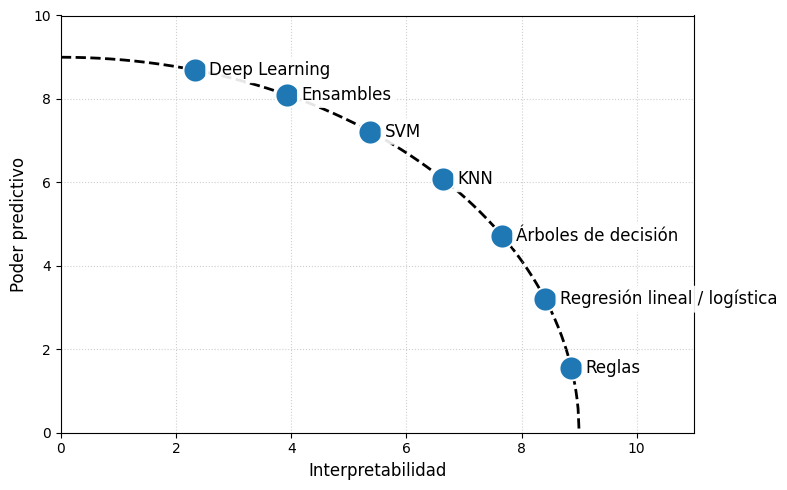

In [7]:
plot_interpretability_frontier(models, add_xai=False)

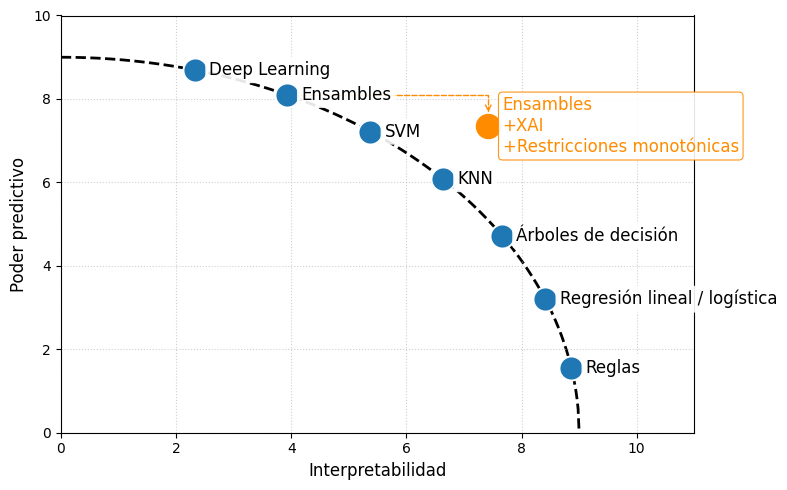

In [8]:
plot_interpretability_frontier(models, add_xai=True)

## Interpretabilidad en modelos de Machine Learning (Cont.)

Al desarrollar modelos de *Machine Learning*, en general se cuenta con conocimiento sobre el problema que se busca modelar. 
Ejemplos:
- **Predicción de precios de propiedades**: Manteniendo el resto de las variables constantes, a mayor superficie ($m^2$), mayor precio.

- **Scoring crediticio**: Manteniendo el resto de las variables constantes, a mayor cantidad de meses con buen comportamiento, menor probabilidad de default.

- **Seguros**: Manteniendo el resto de las variables constantes, a mayor antigüedad del vehículo, mayor probabilidad de falla mecánica.
Las explicaciones de un modelo deberían ser consistentes con las expectativas y conocimientos previos de sus usuarios (molnar2025). Sin embargo, los modelos pueden aprender relaciones que contradicen estas expectativas. Una forma de incorporar conocimiento de dominios es mediante `restricciones monotónicas`.
# Restricciones monotónicas

## Monotonicidad

¿Qué es la monotonicidad?

-   Una función es **monotónica creciente** si, cuando aumenta el valor de entrada, su salida no disminuye:

    -   `Si x1 <= x2: f(x1) <= f(x2)`

-   Una función es **monotónica decreciente** si, cuando aumenta el valor de entrada, su salida no aumenta:

    -   `Si x1 <= x2: f(x1) >= f(x2)`

En machine learning, una **restricción monotónica** fuerza al modelo a respetar una dirección esperada entre una variable y la predicción. 

## Monotonicidad creciente

La función `f(x) = x ** 2` es monotónica creciente para valores de `x >= 0`: si `x` aumenta, `f(x)` también aumenta o se mantiene igual.

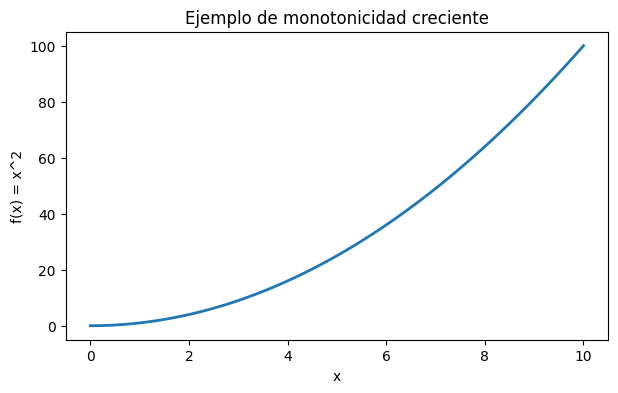

In [9]:
x = np.linspace(0, 10, 100)
y_creciente = x**2

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, y_creciente, linewidth=2)
ax.set(title="Ejemplo de monotonicidad creciente", xlabel="x", ylabel="f(x) = x^2")
plt.show()

## Monotonicidad decreciente

La función `f(x) = exp(-x)` es monotónica decreciente: si `x` aumenta, `f(x)` disminuye.

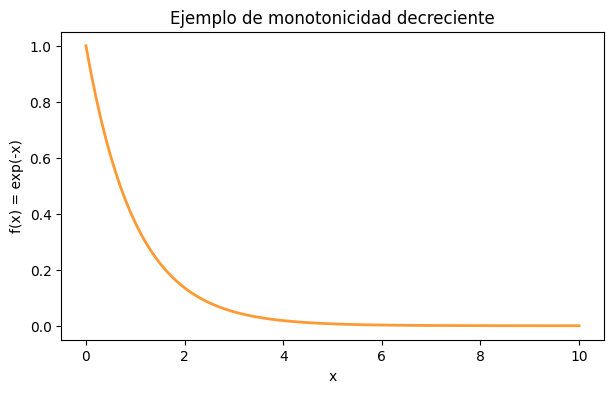

In [10]:
x = np.linspace(0, 10, 100)
y_decreciente = np.exp(-x)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, y_decreciente, color=COLOR_ORANGE, linewidth=2)
ax.set(title="Ejemplo de monotonicidad decreciente", xlabel="x", ylabel="f(x) = exp(-x)")
plt.show()

## Modelos de boosting con restricciones monotónicas
Sea $c_j \in \{-1, +1\}$ el sentido de la restricción para la variable $x_j$:

- $c_j = -1$: restricción decreciente
- $c_j = +1$: restricción creciente

Refiriéndose a la ecuación @eq-boosting-ensemble, para garantizar que el modelo respete la monotonía en la variable $x_j$, se requiere que el nuevo árbol $f_m$ satisfaga:

Para dos observaciones $i, k$, si $x_{i,j} \leq x_{k,j}$ y $x_{i,-j} = x_{k,-j}$, entonces:

$$
c_j \cdot f_m(x_i) \leq c_j \cdot f_m(x_k)
$$

Es decir, el árbol debe ser monotónico en la variable $x_j$ con la dirección especificada por $c_j$.

En cada iteración, el nuevo árbol se busca únicamente dentro del conjunto restringido $F_{\text{mono}}$ de árboles que cumplen esta propiedad:

$$
f_m
=
\underset{f \, \in \, F_{\text{mono}}}{\operatorname{argmin}}\;
\sum_{i=1}^{n}
\underbrace{\color{teal}{L}}_{\color{teal}{\text{función de pérdida}}}
\left(
\underbrace{\color{purple}{y_i}}_{\color{purple}{\text{valor observado}}},
\,
\underbrace{\color{orange}{\widehat{y}_i^{(m-1)}}}_{\color{orange}{\text{predicción anterior}}}
+
\underbrace{\color{red}{f(x_i)}}_{\color{red}{\text{nuevo árbol}}}
\right)
$$ 

donde $F_{\text{mono}} = \left\{ f : c_j \cdot f(x_i) \leq c_j \cdot f(x_k) \text{ si } x_{i,j} \leq x_{k,j}, \, \forall i,k,j \right\}$
## Ejemplo simple

In [11]:
# Simulación de N observaciones:
rng = np.random.default_rng(42)
n = 1_000

# Feature: distribución uniforme entre 18 y 70 años
feature = rng.uniform(18, 70, n)

# Probabilidad base: target=1 decrece con la feature
p = 0.90 - 0.0105 * (feature - 18)

# Ruido en toda la distribución
noise = rng.normal(0, 0.07, n)

# Ruido extra entre 50 y 60 años
high_noise = np.where(
    (feature >= 50) & (feature <= 60),
    rng.normal(0, 0.18, n),
    0
)

# Probabilidad final
p = np.clip(p + noise + high_noise, 0.02, 0.98)

# Variable objetivo binaria
target = rng.binomial(1, p)

df = pd.DataFrame({
    "feature": np.round(feature, 1),
    "target": target
})
X = df[["feature"]]
y = df["target"]

Se utilizan datos simulados para ilustrar el efecto de imponer una restricción monotónica en un modelo de clasificación binaria. El dataset contiene `n` observaciones y 2 columnas: `feature` y `target` (variable binaria: 0 o 1).

In [12]:
def map_color(data):
    return (data["target"] == 0).map(
        {True: COLOR_LIGHTGREEN, False: 'white'}
    )

(
GT(df.sample(4, random_state=1).round(2)
        .set_index("target")
        .reset_index()
    )
    .tab_style(
        style=style.fill(color=map_color), locations=loc.body(columns=df.columns.tolist()),
    )
    .tab_style(
        style=style.text(color=COLOR_ORANGE, weight = "bold"), locations=loc.body("target"),
    )
    .tab_options(
        column_labels_background_color=COLOR_TABLE_HEADER,
        table_font_names="Times New Roman"
    )
)

target,feature
1,61.5
1,50.3
0,54.9
0,35.3


Se espera que la probabilidad del evento `target` disminuya a mayor valor de la variable `feature` pero esa relación no sea estrictamente monotónica en los datos de la muestra. 

## Modelo con restricciones monotónicas

Se ajustan 2 modelos: 

- Modelo estándar (sin restricción monotónica)


In [13]:
# Modelo sin restricción monotónica
modelo_sin_restriccion = HistGradientBoostingClassifier(
    max_depth=3, max_iter=2, learning_rate=0.7, random_state=42
)
modelo_sin_restriccion.fit(X, y)

HistGradientBoostingClassifier(learning_rate=0.7, max_depth=3, max_iter=2,
                               random_state=42)

- Modelo con restricción monotónica decreciente sobre la variable `feature`

In [14]:
# Se genera una copia del modelo anterior:
modelo_con_restriccion = deepcopy(modelo_sin_restriccion)

# Se añade una restricción monotónica decreciente sobre la variable `feature`:
modelo_con_restriccion.set_params(monotonic_cst={"feature": -1})
modelo_con_restriccion.fit(X, y)

HistGradientBoostingClassifier(learning_rate=0.7, max_depth=3, max_iter=2,
                               monotonic_cst={'feature': -1}, random_state=42)

## Modelo con restricciones monotónicas (Cont.)

`HistGradientBoostingClassifier` almacena los árboles que componen el modelo (internamente como `TreePredictor`). Se utiliza una función para visualizar los 2 árboles (`max_iter=2`) que componen cada uno de los modelos ajustados.
### Sin restricción

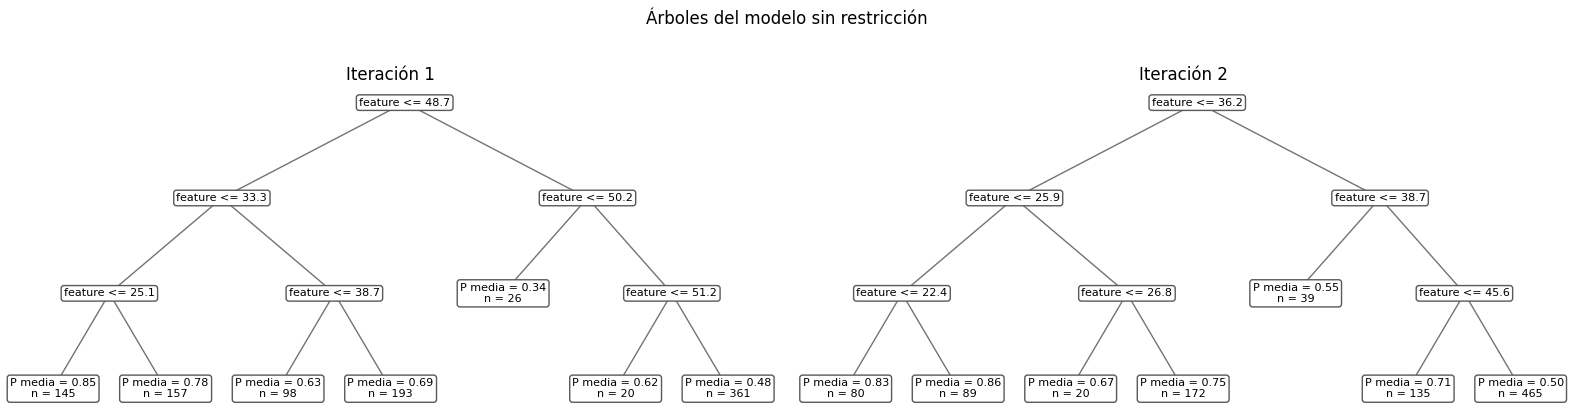

In [15]:
from utils.plot_trees import plot_hist_gradient_boosting_tree

fig, axes = plt.subplots(1, modelo_sin_restriccion.max_iter, figsize=(16, 4))
for iteration, ax in enumerate(np.atleast_1d(axes)):
    plot_hist_gradient_boosting_tree(
        modelo_sin_restriccion,
        iteration,
        feature_names=["feature"],
        X_reference=X,
        ax=ax,
    )
fig.suptitle("Árboles del modelo sin restricción", y=1.02)
plt.tight_layout()
plt.show()

### Con restricción

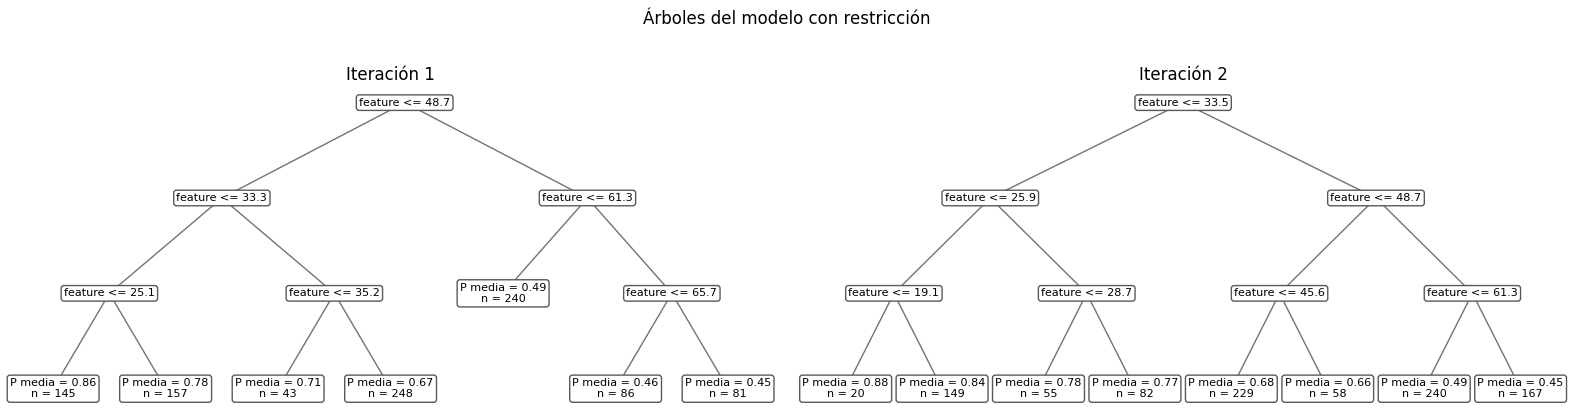

In [16]:
fig, axes = plt.subplots(1, modelo_con_restriccion.max_iter, figsize=(16, 4))
for iteration, ax in enumerate(np.atleast_1d(axes)):
    plot_hist_gradient_boosting_tree(
        modelo_con_restriccion,
        iteration,
        feature_names=["feature"],
        X_reference=X,
        ax=ax,
    )
fig.suptitle("Árboles del modelo con restricción", y=1.02)
plt.tight_layout()
plt.show()

## Modelo con restricciones monotónicas (Cont.)
En la @fig-example1 se comparan las predicciones de los modelos con y sin restricción monotónica decreciente sobre la variable `feature`. La **dependencia parcial** muestra cómo cambia, en promedio, la predicción cuando se modifica una variable manteniendo el resto de las variables constantes:

- **Modelo sin restricción**: la probabilidad aumenta en ciertos valores (contraintuitivo, se espera que disminuya con la `feature`).
- **Modelo con restricción**: respeta la relación esperada entre la `feature` y la probabilidad.

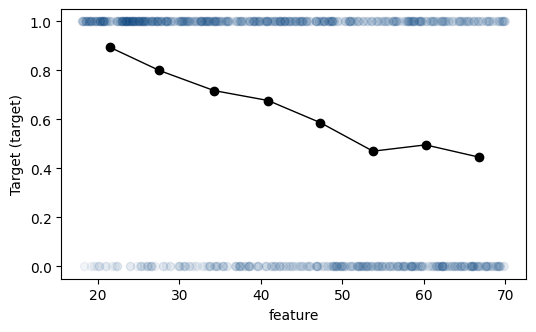

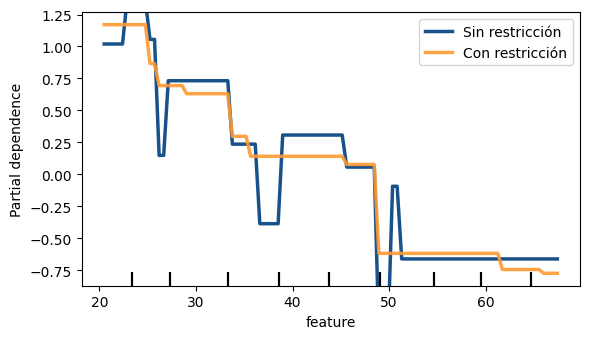

In [17]:
from utils.eval import plot_monotonic_comparison
plot_monotonic_comparison(
    df,
    feature="feature",
    target="target",
    modelo_sin_restriccion=modelo_sin_restriccion,
    modelo_con_restriccion=modelo_con_restriccion,
    fig_width=6,
    fig_height=3.5,
)

# Caso: scoring crediticio

## Datos

Give me some credit (GiveMeSomeCredit) es un dataset de scoring crediticio con información financiera y demográfica de individuos. El objetivo es modelar el riesgo de incumplimiento (*default*) a partir de esas características.

In [21]:
df = pd.read_csv(f"{PATH_DATA}/cs-training.csv").drop("Unnamed: 0", axis=1)

df["DebtRatio"] = df["DebtRatio"].clip(0, 1)

TARGET = "SeriousDlqin2yrs"
FEATURES = [
    "DebtRatio", 
    "age",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans"
]

df = df[FEATURES + [TARGET]]
X = df.drop(TARGET, axis=1)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [22]:
N_OBSERVACIONES = df.shape[0]
N_VARIABLES = df.shape[1]
PERC_DEFAULT = y.mean()

N_TRAIN = X_train.shape[0]
N_TEST = X_test.shape[0]

Se cuenta con un dataset de `N_OBSERVACIONES` observaciones y `N_VARIABLES` variables:

- `N_TRAIN` observaciones en el dataset de entrenamiento
- `N_TEST` en el dataset de evaluación.
Se busca responder los siguientes interrogantes:
> - ¿Cuál es la probabilidad de *default* de un individuo dadas ciertas características?
> - ¿Cómo cambia esa probabilidad para un individuo si aumenta una variable, manteniendo el resto de las variables constantes?

## Análisis exploratorio de datos

In [23]:
def median_iqr(x):
    q25, q50, q75 = np.percentile(x.dropna(), [25, 50, 75])
    return f"{q50:.2f} [{q25:.2f} - {q75:.2f}]"

eda_table = (
    df.groupby(TARGET)[FEATURES]
    .agg(median_iqr)
    .T
    .reset_index()
    .rename(columns={"index": "Variable", 0: f"{TARGET}=0", 1: f"{TARGET}=1"})
)

(
    GT(eda_table)
    .tab_header(
        title="Resumen Comparativo de Variables",
        subtitle="Valores expresados como Mediana [Q1 - Q3]"
    )
    .cols_align(align="center", columns=[f"{TARGET}=0", f"{TARGET}=1"])
)

GT(_tbl_data=SeriousDlqin2yrs                         Variable  \
0                                       DebtRatio   
1                                             age   
2                                   MonthlyIncome   
3                 NumberOfOpenCreditLinesAndLoans   

SeriousDlqin2yrs           SeriousDlqin2yrs=0           SeriousDlqin2yrs=1  
0                          0.36 [0.17 - 0.87]           0.43 [0.19 - 0.89]  
1                       52.00 [42.00 - 63.00]        45.00 [36.00 - 54.00]  
2                 5466.00 [3461.00 - 8333.00]  4500.00 [2963.00 - 6800.00]  
3                         8.00 [5.00 - 11.00]          7.00 [4.00 - 11.00]  , _body=<great_tables._gt_data.Body object at 0x13e4232c0>, _boxhead=Boxhead([ColInfo(var='Variable', type=<ColInfoTypeEnum.default: 1>, column_label='Variable', column_align='left', column_width=None), ColInfo(var='SeriousDlqin2yrs=0', type=<ColInfoTypeEnum.default: 1>, column_label='SeriousDlqin2yrs=0', column_align='center', column_width=None), ColInfo(var='SeriousDlqin2yrs=1', type=<ColInfoTypeEnum.default: 1>, column_label='SeriousDlqin2yrs=1', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x13e420c50>, _spanners=Spanners([]), _heading=Heading(title='Resumen Comparativo de Variables', subtitle='Valores expresados como Mediana [Q1 - Q3]', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x13e3044a0>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=Option

La variable `DebtRatio` mide la relación entre deuda e ingreso mensual. Para el modelo se acota al intervalo $[0, 1]$, evitando que valores extremos dominen la visualización.

## Modelo 

In [24]:
modelo_sin_restriccion_credito = HistGradientBoostingClassifier(
    max_iter=100,
    max_depth=10,
    learning_rate=0.7,
    verbose=0,
    random_state=42,
)
modelo_sin_restriccion_credito.fit(X_train, y_train)

HistGradientBoostingClassifier(learning_rate=0.7, max_depth=10, random_state=42)

El primer modelo no incorpora restricciones. Su flexibilidad permite capturar relaciones complejas, pero también puede producir cambios contraintuitivos en regiones con pocos datos.

## Modelo con restricciones monotónicas

Se espera que un mayor endeudamiento no reduzca el riesgo de incumplimiento. Por eso se impone una restricción monotónica creciente sobre `DebtRatio`.

In [25]:
restricciones = {"DebtRatio": 1}

modelo_con_restriccion_credito = deepcopy(modelo_sin_restriccion_credito)
modelo_con_restriccion_credito.set_params(monotonic_cst=restricciones)
modelo_con_restriccion_credito.fit(X_train, y_train)

HistGradientBoostingClassifier(learning_rate=0.7, max_depth=10,
                               monotonic_cst={'DebtRatio': 1}, random_state=42)

La restricción no obliga a que todos los individuos tengan el mismo riesgo. Obliga a que, manteniendo las demás variables constantes, el riesgo estimado no disminuya cuando aumenta `DebtRatio`.

## Comparación de modelos

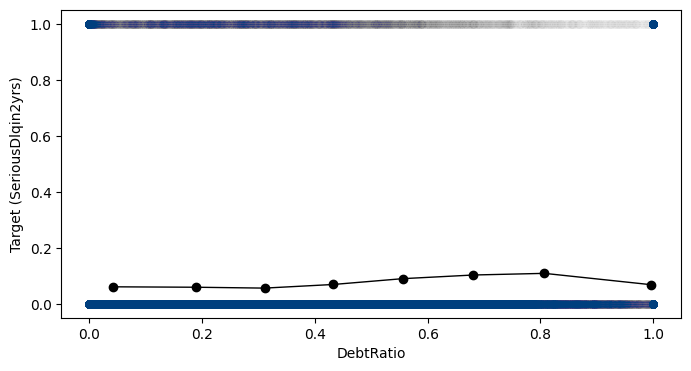

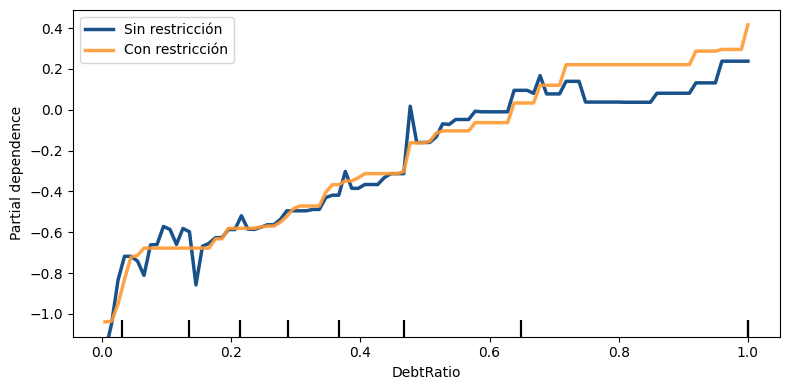

In [26]:
plot_monotonic_comparison(
    df,
    feature="DebtRatio",
    target=TARGET,
    modelo_sin_restriccion=modelo_sin_restriccion_credito,
    modelo_con_restriccion=modelo_con_restriccion_credito,
    alpha=0.005,
)

## Simulación de cambio en DebtRatio

In [27]:
initial_value = 0.1
new_value = 0.15

Se obtiene una observación de X:

In [28]:
X_1 = X.sample(1, random_state=42)
X_1 = X_1.assign(DebtRatio=initial_value)
X_2 = X_1.assign(DebtRatio=new_value)

display(GT(X_1))

df_compare = pd.DataFrame(
    {
        "Modelo": ["Sin restricción", "Con restricción"],
        "P_{}".format(initial_value): [
            modelo_sin_restriccion_credito.predict_proba(X_1)[:, 1][0],
            modelo_con_restriccion_credito.predict_proba(X_1)[:, 1][0],
        ],
        "P_{}".format(new_value): [
            modelo_sin_restriccion_credito.predict_proba(X_2)[:, 1][0],
            modelo_con_restriccion_credito.predict_proba(X_2)[:, 1][0],
        ],
    }
).assign(variation=lambda x: x[f"P_{new_value}"] - x[f"P_{initial_value}"])

DebtRatio,age,MonthlyIncome,NumberOfOpenCreditLinesAndLoans
0.1,57,10121.0,7


Se incrementa su `DebtRatio` de `initial_value` a `new_value`. El modelo restringido mantiene el sentido esperado del cambio: un aumento en `DebtRatio` no puede producir una reducción de la probabilidad de *default*.

In [29]:
(GT(df_compare)
    .fmt_percent(columns=["P_{}".format(initial_value), "P_{}".format(new_value), "variation"], decimals=2)
    .cols_label(
        **{"P_{}".format(initial_value): f"DebtRatio = {initial_value}"},
        **{"P_{}".format(new_value): f"DebtRatio = {new_value}"},
        **{"variation": "△ %"}
    )
    .tab_spanner(
        label="P(default)",
        columns=["P_{}".format(initial_value), f"P_{new_value}"],
    )
    .tab_style(
        style=style.borders(sides="right", color=COLOR_ORANGE, weight="1px"),
        locations=loc.body(columns=f"P_{new_value}"),
    )
    .tab_options(
        column_labels_background_color=COLOR_TABLE_HEADER,
        table_font_names="Times New Roman"
    )
)

GT(_tbl_data=            Modelo     P_0.1    P_0.15  variation
0  Sin restricción  0.024210  0.021014  -0.003197
1  Con restricción  0.017442  0.017442   0.000000, _body=<great_tables._gt_data.Body object at 0x13ecb47a0>, _boxhead=Boxhead([ColInfo(var='Modelo', type=<ColInfoTypeEnum.default: 1>, column_label='Modelo', column_align='left', column_width=None), ColInfo(var='P_0.1', type=<ColInfoTypeEnum.default: 1>, column_label='DebtRatio = 0.1', column_align='right', column_width=None), ColInfo(var='P_0.15', type=<ColInfoTypeEnum.default: 1>, column_label='DebtRatio = 0.15', column_align='right', column_width=None), ColInfo(var='variation', type=<ColInfoTypeEnum.default: 1>, column_label='△ %', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x13e43a0f0>, _spanners=Spanners([SpannerInfo(spanner_id='P(default)', spanner_level=0, spanner_label='P(default)', spanner_units=None, spanner_pattern=None, vars=['P_0.1', 'P_0.15'], built=None)]), _heading=Heading(title=None, subtitle=None, preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname='data', locnum=5, grpname=None, colname='P_0.15', rownum=0, colnum=None, styles=[CellStyleBorders(sides='right', color='#FF9933', style='solid', weight='1px')]), StyleInfo(locname='data', locnum=5, grpname=None, colname='P_0.15', rownum=1, colnum=None, styles=[CellStyleBorders(sides='right', color='#FF9933', style='solid', weight='1px')])], _locale=<great_tables._gt_data.Locale object at 0x13ecb4140>, _formats=[<great_tables._gt_data.FormatInfo object at 0x13ecb6750>], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['Times New Roman']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss=True, category='table', type='px', value=

## Human in the loop

Las restricciones monotónicas muestran una idea más amplia: **la supervisión humana no termina cuando el modelo empieza a predecir**.

En el contexto actual de la inteligencia artificial, no alcanza con preguntar si un sistema es preciso. También debemos preguntarnos:

> ¿Es consistente con lo que sabemos, podemos explicar sus decisiones y quién responde cuando se equivoca?

La IA puede ampliar nuestras capacidades, pero las decisiones con impacto requieren **criterio humano, controles y responsabilidad**.